# Backtest

## Objectives

Backtest the preliminary model, find weaknesses, and explore potential interactions and transformations.

##  Libraries

In [1]:
library(car)
library(tidyverse)
library(here)
library(DHARMa)

Loading required package: carData

Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.6.0
v ggplot2   4.0.1     v tibble    3.2.1
v lubridate 1.9.4     v tidyr     1.3.1
v purrr     1.2.1     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
x dplyr::recode() masks car::recode()
x purrr::some()   masks car::some()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
here() starts at /Users/eialnisman/Desktop/WC2026Forecast

This is DHARMa 0.4.7. For overview type '?DHARMa'. For recent changes, type news(package = 'DHARMa')



## Dataset

In [13]:
Training <- readRDS(here("1.DataCleaning-R", "Data", "RDS", "FinalTrainingDS.rds"))

## Backtest

Let's fit the model we developed in the previous notebooks and test it.

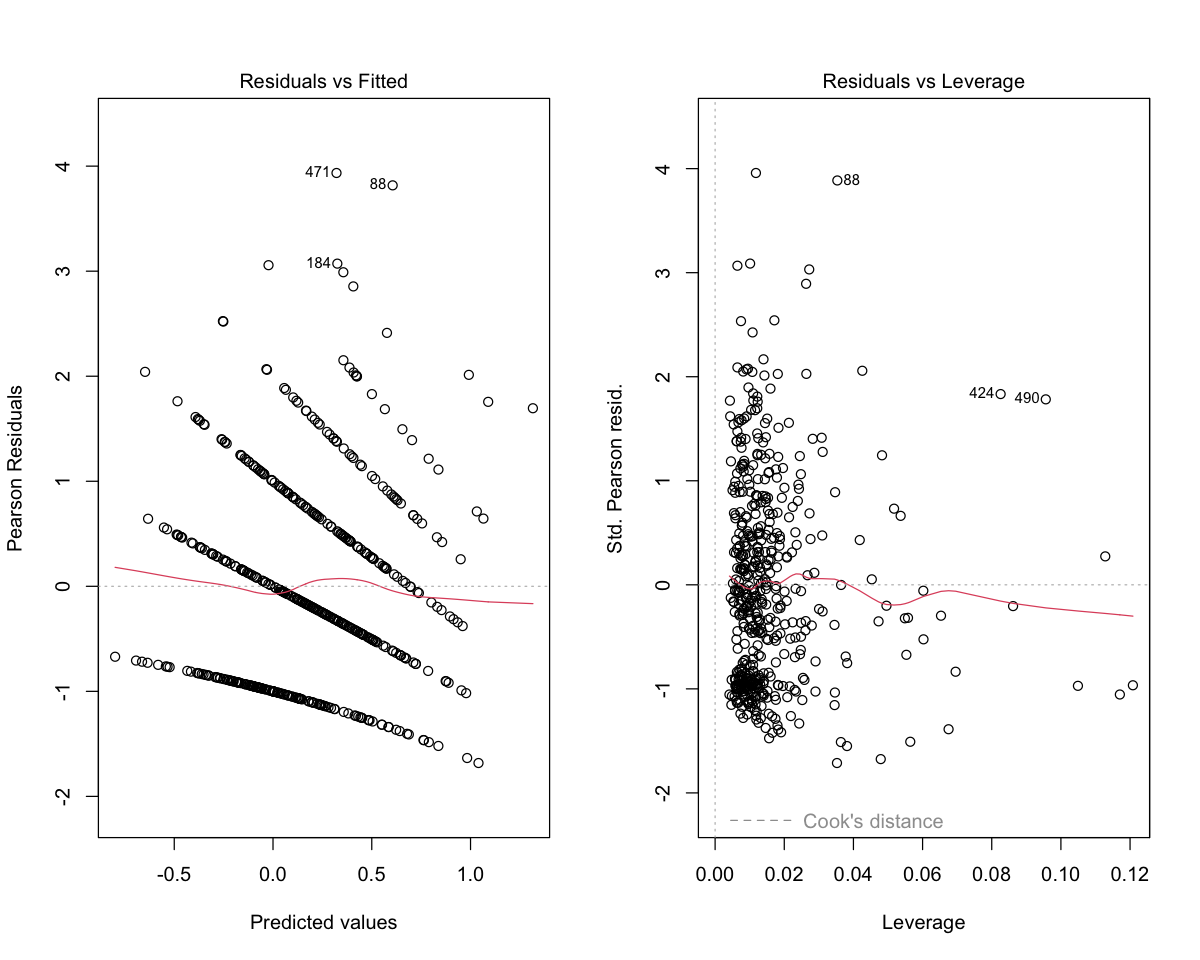

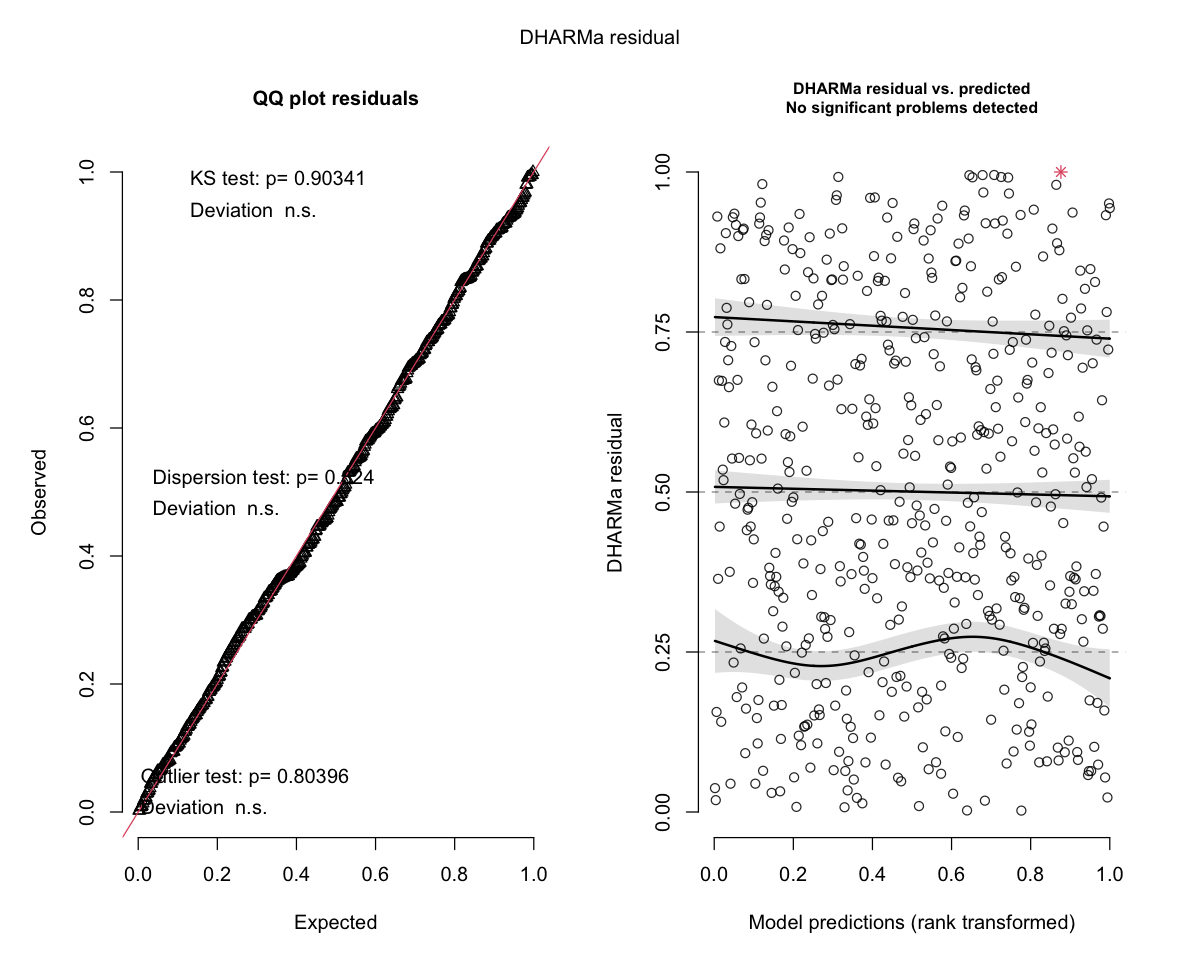

In [7]:
m1 <- glm(goals_for ~ ELO_diff + opp_prior_world_cups_coached + opp_players_with_multiple_prior_wcs+I(avg_age**2)+opp_avg_age+I(opp_avg_age**2) + distance_from_host_km, family=poisson, Training) 

simres <- simulateResiduals(m1)

options(repr.plot.width = 10,
        repr.plot.height = 8)
par(mfrow = c(1, 2))
plot(m1, which = c(1,5))
plot(simres)

In [8]:
deviance(m1) / df.residual(m1)

[1] 1.119667

<div style="font-family: Arial; line-height: 1.6; border: 1px solid #ddd; padding: 16px; border-radius: 10px; max-width: 700px;">

  <h2>🧪 Poisson Model Diagnostics</h2>

  <p><b>✅ Overdispersion:</b> Residual deviance / df ≈ 1.12.</p>
  <p>This suggests the Poisson variance assumption is reasonable.</p>

  <p><b>✅ DHARMa Uniformity Test:</b> KS test p = 0.903.</p>
  <p>No evidence that simulated residuals deviate from the expected distribution.</p>

  <p><b>✅ DHARMa Dispersion Test:</b> p = 0.524.</p>
  <p>No significant overdispersion or underdispersion was detected. The Poisson assumption that E[Y∣X]=Var[Y∣X] appears consistent with the observed data.</p>

  <p><b>✅ Outlier Test:</b> p = 0.804.</p>
  <p>The test is not statistically significant. No evidence of unusual outliers was detected, suggesting that extreme observations are unlikely to be materially influencing model forecasts.</p>

  <p><b>✅ Residuals vs Predicted:</b> No significant pattern detected.</p>
  <p>The model does not show strong evidence of systematic bias across fitted values.</p>

  <hr>

  <p><b>Overall conclusion:</b> The Poisson GLM appears statistically adequate for modeling World Cup team goals.</p>

</div>

## K-fold out of sample testing

In [12]:
set.seed(2025)

# ---------------------------
# SETTINGS
# ---------------------------

k <- 5
n_repeats <- 100

Games_cv <- Training

cv_results <- data.frame()

# ---------------------------
# REPEATED K-FOLD CV
# ---------------------------

for(rep in 1:n_repeats){

    Games_cv$fold <- sample(rep(1:k, length.out = nrow(Games_cv)))

    for(f in 1:k){

        train <- Games_cv %>%
            filter(fold != f)

        test <- Games_cv %>%
            filter(fold == f)

        model <- glm(goals_for ~ ELO_diff + 
        opp_prior_world_cups_coached + 
        opp_players_with_multiple_prior_wcs+I(avg_age**2)+
        opp_avg_age+I(opp_avg_age**2) + 
        distance_from_host_km, 
        family=poisson, train
        )

        lambda <- predict(
            model,
            newdata = test,
            type = "response"
        )

        actual <- test$goals_for

        fold_results <- data.frame(
            Repeat = rep,
            Fold = f,

            LogLoss = -mean(
                dpois(actual, lambda = lambda, log = TRUE)
            ),

            MAE = mean(
                abs(actual - lambda)
            ),

            RMSE = sqrt(
                mean((actual - lambda)^2)
            ),

            Bias = mean(
                lambda - actual
            ),

            Correlation = cor(
                actual,
                lambda,
                use = "complete.obs"
            )
        )

        cv_results <- bind_rows(
            cv_results,
            fold_results
        )
    }
}

# ---------------------------
# SUMMARY TABLE
# ---------------------------

cv_summary <- cv_results %>%
    summarize(
        Mean_LogLoss = mean(LogLoss),
        SD_LogLoss = sd(LogLoss),

        Mean_MAE = mean(MAE),
        SD_MAE = sd(MAE),

        Mean_RMSE = mean(RMSE),
        SD_RMSE = sd(RMSE),

        Mean_Bias = mean(Bias),
        SD_Bias = sd(Bias),

        Mean_Correlation = mean(Correlation),
        SD_Correlation = sd(Correlation)
    )

cv_summary

Mean_LogLoss,SD_LogLoss,Mean_MAE,SD_MAE,Mean_RMSE,SD_RMSE,Mean_Bias,SD_Bias,Mean_Correlation,SD_Correlation
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1.41417,0.06137813,0.8923362,0.06007027,1.13669,0.09183073,0.0005163083,0.1264956,0.3564273,0.09197983


<div style="font-family: Arial; line-height: 1.6; border: 1px solid #ddd; padding: 16px; border-radius: 10px; max-width: 850px;">

  <h2>📊 Interpreting the Out-of-Sample Metrics</h2>

  <p>
    <b>🎯 Log Loss:</b> The model achieved an average out-of-sample log loss of <b>1.414</b>.
    This indicates that the model is assigning relatively high probability to the outcomes that actually occur.
    Since log loss evaluates the entire predicted probability distribution rather than only the most likely score, it is the most important metric for assessing the quality of a probabilistic Poisson forecasting model.
  </p>

  <p>
    <b>📏 MAE:</b> The model has an average Mean Absolute Error (MAE) of approximately <b>0.89 goals</b>.
    This means that the predicted expected goals are typically within about one goal of the realized score.
    Given the low-scoring and highly random nature of football matches, this represents a reasonable level of predictive accuracy.
  </p>

  <p>
    <b>📉 RMSE:</b> The model has an average Root Mean Squared Error (RMSE) of approximately <b>1.14 goals</b>.
    Because RMSE penalizes large errors more heavily than MAE, the fact that RMSE exceeds MAE suggests that a small number of matches produced larger forecasting errors.
    Such outcomes are expected in footbal due to occasional high-scoring matches and other unpredictable events.
  </p>

  <p>
    <b>⚖️ Bias:</b> The model's average bias is approximately <b>0.0005 goals</b>, which is effectively zero.
    This indicates that the model is neither systematically overpredicting nor underpredicting goals.
    On average, forecasted goal totals are extremely well calibrated to observed outcomes.
  </p>

  <p>
    <b>🔗 Correlation:</b> The average correlation between predicted and observed goals is approximately <b>0.356</b>.
    While this may appear modest compared to many regression applications, it is quite reasonable for football forecasting.
    Match-level goal counts contain substantial randomness, meaning even well-specified models will only explain a portion of the variation in realized scores.
  </p>

  <hr>

  <p>
    <b>📈 Stability Across Simulations:</b> The relatively small standard deviations across the repeated train-test simulations suggest that model performance is stable.
    In particular, the log loss standard deviation of approximately <b>0.061</b> indicates that forecasting quality remains consistent across different data splits, reducing concerns about overfitting to a particular sample.
  </p>

  <p>
    <b>Overall interpretation:</b> The model performs well out of sample and exhibits several desirable forecasting characteristics: a competitive log loss, an average prediction error below one goal, essentially zero bias, and a meaningful positive correlation between predictions and observed outcomes. Combined with the favorable Poisson diagnostic tests, these results suggest that the model is a credible goal-generation model capable of producing useful probability distributions for World Cup match forecasting.
  </p>

</div>

### Prepare the model or export to R

In [18]:
coef_table <- data.frame(term = names(coef(m1)),estimate = as.numeric(coef(m1)))

write.csv(coef_table, here("2.Model_Selection-R","poisson_model_coefficients.csv"), row.names = FALSE)